<a href="https://colab.research.google.com/github/cookie98259702-stack/Project/blob/main/Ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wavelets & Approximation — Lab Notebook

**Sparse & Redundant Representations** · companion to the handout *Wavelets & Approximation*.

Work through the Parts **in order**. Read the matching Part in the handout, then fill in the
`# TODO` cells here. Each Part ends with a short **Deliverable** to keep for your report.

- Core library: **PyWavelets** (`pywt`). Also `numpy`, `scikit-image` (metrics + fallback images), `matplotlib`.
- Run the setup cell first. It defines a few helpers so you can focus on the wavelet ideas, not boilerplate.
- Use `mode='periodization'` everywhere (kept in the constant `MODE`) so the transform stays critically sampled.


In [ ]:
# === Setup & helpers (given — run me first) ==============================
import numpy as np
import pywt
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from skimage.metrics import structural_similarity as _ssim
    import skimage.data as skdata
    _HAVE_SK = True
except Exception:
    _HAVE_SK = False

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print("PyWavelets", pywt.__version__, "| scikit-image available:", _HAVE_SK)

MODE = 'periodization'          # critically-sampled boundary handling
IMG_DIR = Path('images')        # image files that ship with the lab

def load_image(name='barbara', size=512):
    """Grayscale image in [0,255] as float64, center-cropped to `size`x`size`.
    Looks in ./images/ ; falls back to a skimage built-in so the notebook always runs."""
    from PIL import Image
    for p in [IMG_DIR/f'{name}.png', IMG_DIR/f'{name}.jpg',
              Path(f'{name}.png'), Path(f'{name}.jpg'), Path(name)]:
        if p.exists():
            arr = np.array(Image.open(p).convert('L'), dtype=np.float64)
            break
    else:
        if not _HAVE_SK:
            raise FileNotFoundError(f"'{name}' not found and scikit-image unavailable.")
        print(f"[load_image] '{name}' not in ./images/ — using skimage.data.camera().")
        arr = skdata.camera().astype(np.float64)
    h, w = arr.shape
    s = min(h, w, size)
    r0, c0 = (h - s) // 2, (w - s) // 2
    return arr[r0:r0 + s, c0:c0 + s]

def psnr(a, b, data_range=255.0):
    """Peak signal-to-noise ratio in dB."""
    mse = np.mean((a.astype(float) - b.astype(float)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(data_range ** 2 / mse)

def ssim(a, b, data_range=255.0):
    """Structural similarity (needs scikit-image; returns nan otherwise)."""
    return _ssim(a, b, data_range=data_range) if _HAVE_SK else np.nan

def show(images, titles=None, cmap='gray', figsize=None, suptitle=None):
    """Display one or more 2-D arrays side by side (auto-clips to [0,255] for grayscale)."""
    if isinstance(images, np.ndarray):
        images = [images]
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize or (4.2 * n, 4.2))
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(np.clip(images[i], 0, 255) if cmap == 'gray' else images[i], cmap=cmap)
        if titles is not None:
            ax.set_title(titles[i])
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout(); plt.show()

# --- coefficient (un)packing: thin wrappers over PyWavelets, given to save boilerplate ---
def flatten_coeffs(coeffs):
    """wavedec2 nested list  ->  (flat 2-D array, slices)."""
    return pywt.coeffs_to_array(coeffs)

def unflatten_coeffs(arr, slices):
    """(flat 2-D array, slices)  ->  wavedec2 nested list."""
    return pywt.array_to_coeffs(arr, slices, output_format='wavedec2')

def scale_index_array(coeffs, slices, level):
    """Array (shape of the packed coeffs) giving each coefficient's SCALE:
    0 = coarse approximation, 1 = coarsest detail shell, ..., `level` = finest.
    Useful for LINEAR approximation (keep the coarsest coefficients)."""
    idx = np.full(pywt.coeffs_to_array(coeffs)[0].shape, level + 1, dtype=int)
    idx[slices[0]] = 0
    for lev, d in enumerate(slices[1:], start=1):
        for key in ('ad', 'da', 'dd'):
            idx[d[key]] = lev
    return idx

print("Helpers ready: load_image, psnr, ssim, show, flatten_coeffs, unflatten_coeffs, scale_index_array")


PyWavelets 1.8.0 | scikit-image available: True
Helpers ready: load_image, psnr, ssim, show, flatten_coeffs, unflatten_coeffs, scale_index_array


## Part 0 — Setup & warm-up  ·  ~15 min

**Goal:** get running and see a wavelet transform for the first time.

1. Load an image and display it.
2. Run one single-level 2-D transform with `pywt.dwt2`.
3. Display the four subbands and identify the blurred average vs the edge details.


image shape: (512, 512) range: 7.0 - 255.0


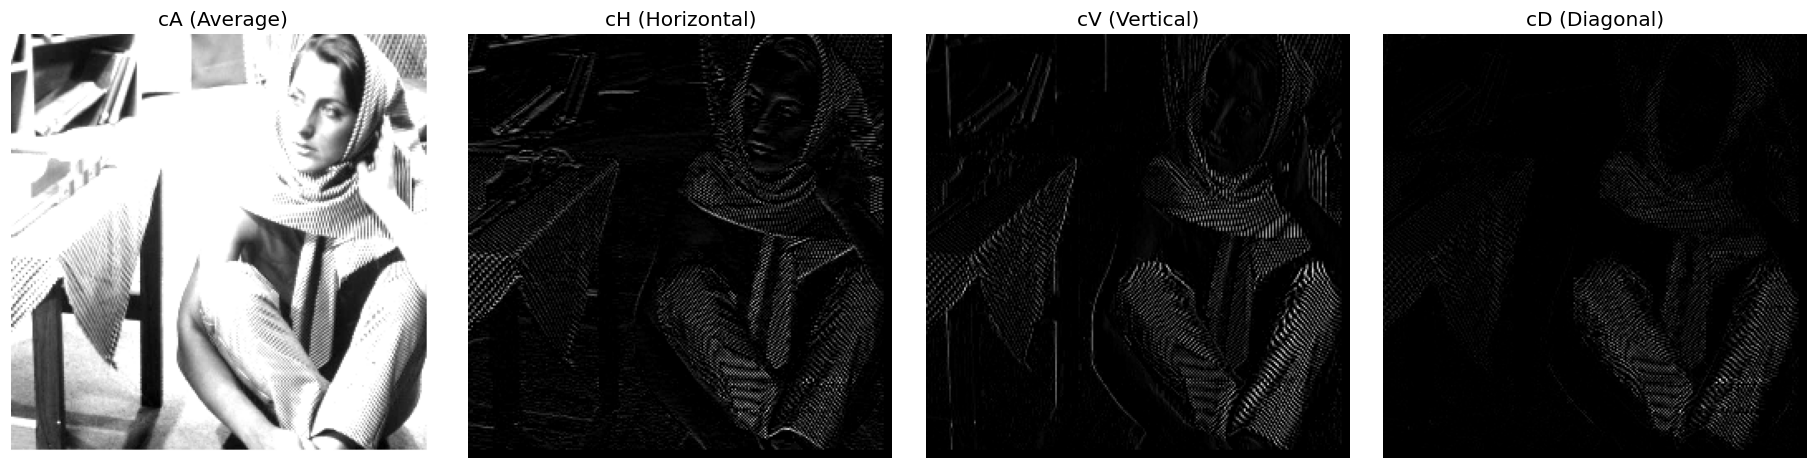

In [ ]:
# Part 0 — load an image, one DWT stage, view the four subbands
img = load_image('barbara', size=512)
print("image shape:", img.shape, "range:", img.min(), "-", img.max())

# TODO: single-level 2-D transform. pywt.dwt2 returns  cA, (cH, cV, cD)
cA, (cH, cV, cD) = pywt.dwt2(img, 'haar')

# TODO: display cA, cH, cV, cD with show([...], titles=[...])
show([cA, cH, cV, cD], titles=['cA (Average)', 'cH (Horizontal)', 'cV (Vertical)', 'cD (Diagonal)'])


## Part 1 — The filter bank up close  ·  ~30 min

**Goal:** stop treating the DWT as a black box. Inspect the filters, then rebuild one stage yourself
and verify **perfect reconstruction**.


### 1a — Inspect the filters
For several wavelets, print the low-pass filter length and the number of vanishing moments.
Confirm the Daubechies rule *support = 2p − 1*.

In [ ]:
import pywt

wavelet_names = ['haar', 'db2', 'db4', 'bior2.2', 'bior4.4']

for name in wavelet_names:
    w = pywt.Wavelet(name)
    filter_len = len(w.dec_lo)
    p = w.vanishing_moments_psi

    print(f"Wavelet: {name}")
    print(f"  Filter length: {filter_len}")
    print(f"  Vanishing moments (p): {p}")

    # 檢驗 Daubechies 規則
    if name.startswith('db') or name == 'haar':
        support = filter_len - 1
        rule_val = 2 * p - 1
        print(f"  Daubechies Rule (support = 2p - 1): {support} == {rule_val} -> {support == rule_val}")
    print("-" * 30)


Wavelet: haar
  Filter length: 2
  Vanishing moments (p): 1
  Daubechies Rule (support = 2p - 1): 1 == 1 -> True
------------------------------
Wavelet: db2
  Filter length: 4
  Vanishing moments (p): 2
  Daubechies Rule (support = 2p - 1): 3 == 3 -> True
------------------------------
Wavelet: db4
  Filter length: 8
  Vanishing moments (p): 4
  Daubechies Rule (support = 2p - 1): 7 == 7 -> True
------------------------------
Wavelet: bior2.2
  Filter length: 6
  Vanishing moments (p): 2
------------------------------
Wavelet: bior4.4
  Filter length: 10
  Vanishing moments (p): 4
------------------------------


### 1b — Low-pass vs high-pass
Plot the `db4` decomposition filters and check the DC gains:
a low-pass filter sums to $\sqrt2$; a high-pass filter sums to (about) 0.

Sum of h (Low-pass): 1.414214 (Expected: ~1.414214)
Sum of g (High-pass): 0.000000 (Expected: ~0.0)


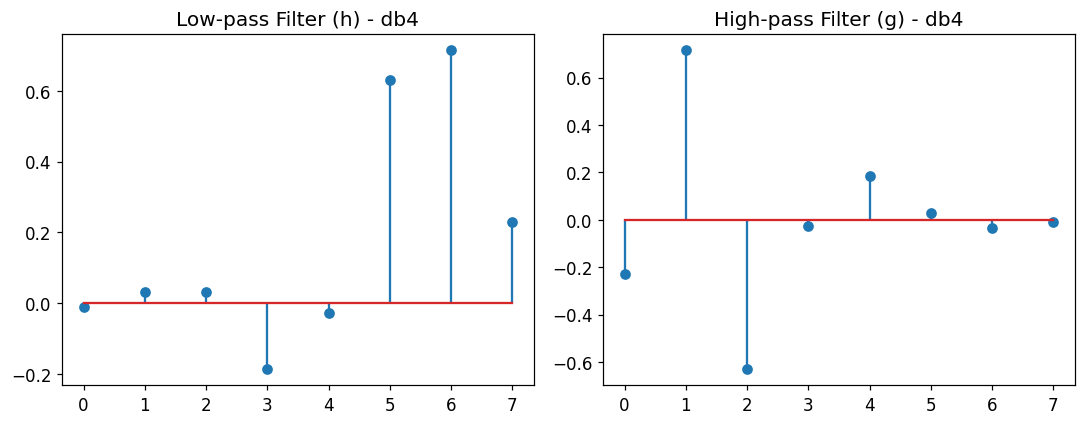

In [ ]:
# 1b — visualise the two filters and check DC gain
import pywt
import numpy as np
import matplotlib.pyplot as plt

w = pywt.Wavelet('db4')
h, g = np.array(w.dec_lo), np.array(w.dec_hi)

print(f"Sum of h (Low-pass): {np.sum(h):.6f} (Expected: ~{np.sqrt(2):.6f})")
print(f"Sum of g (High-pass): {np.sum(g):.6f} (Expected: ~0.0)")

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.stem(h)
ax1.set_title("Low-pass Filter (h) - db4")

ax2 = fig.add_subplot(1, 2, 2)
ax2.stem(g)
ax2.set_title("High-pass Filter (g) - db4")

plt.tight_layout()
plt.show()


### 1c — Build one stage by hand (the core task)
Implement analysis (**circular convolution, then keep every second sample**) and synthesis
(**zero-insert upsampling, circular convolution, then sum**). Verify perfect reconstruction.

*Hint:* an orthogonal filter bank reconstructs up to a fixed circular **delay of $L-1$** samples —
undo it with `np.roll`. The assertion tells you when it is right.

In [ ]:
# 1c — a hand-built 1-D two-channel filter bank
import pywt
import numpy as np

def circ_filter_down(x, f):
    """Circular convolution of x with filter f, then downsample by 2 (keep even indices)."""
    N, L = len(x), len(f)
    # TODO: circular convolution y[n] = sum_k f[k] * x[(n-k) mod N], then return y[::2]

    x_pad = np.pad(x, (L - 1, 0), mode='wrap')
    y = np.convolve(x_pad, f, mode='valid')
    return y[::2]

def up_circ_filter(c, f, N):
    """Zero-insert upsample c to length N, then circular convolution with filter f."""
    up = np.zeros(N)
    up[::2] = c
    L = len(f)
    # TODO: circular convolution of `up` with f, length N

    up_pad = np.pad(up, (L - 1, 0), mode='wrap')
    y = np.convolve(up_pad, f, mode='valid')
    return y

def analysis_1d(x, wavelet):
    w = pywt.Wavelet(wavelet)
    # TODO: return (approximation, detail) using dec_lo and dec_hi
    a = circ_filter_down(x, w.dec_lo)
    d = circ_filter_down(x, w.dec_hi)
    return a, d

def synthesis_1d(a, d, wavelet):
    w = pywt.Wavelet(wavelet)
    N = 2 * len(a)
    L = len(w.rec_lo)

    # TODO: upsample+filter a with rec_lo and d with rec_hi, sum them,
    #       then undo the circular delay of (L-1) samples with np.roll.
    y_a = up_circ_filter(a, w.rec_lo, N)
    y_d = up_circ_filter(d, w.rec_hi, N)
    y = y_a + y_d

    return np.roll(y, -(L - 1))

# verify perfect reconstruction (leave this assertion in place)
rng = np.random.default_rng(0)
for wv in ['haar', 'db2', 'db4']:
    x = rng.standard_normal(32)
    a, d = analysis_1d(x, wv)
    xr = synthesis_1d(a, d, wv)
    err = np.max(np.abs(xr - x))
    print(f"{wv:5s}  perfect-reconstruction error = {err:.2e}")
    assert err < 1e-9, f"{wv}: reconstruction is not exact yet"
print("Perfect reconstruction verified.")


haar   perfect-reconstruction error = 4.44e-16
db2    perfect-reconstruction error = 6.66e-16
db4    perfect-reconstruction error = 4.44e-16
Perfect reconstruction verified.


### 1d — Non-redundancy
Pack a 3-level 2-D transform into one array and confirm it has exactly $N$ entries.

In [ ]:
# 1d — the transform is critically sampled: coefficient count == N
import pywt

# Run a 3-level 2D transform.
# mode='periodization' is strictly required here so the boundaries do not add extra coefficients.
coeffs = pywt.wavedec2(img, 'db4', mode='periodization', level=3)

# Flatten the coefficients into a single array
arr, coeff_slices = pywt.coeffs_to_array(coeffs)

# Compare arr.size to img.size
print(f"Original image size (N): {img.size}")
print(f"Flattened coefficients size: {arr.size}")

assert arr.size == img.size, "Size mismatch: coefficient count is not exactly N."
print("Perfect match: The transform is non-redundant and critically sampled.")


Original image size (N): 262144
Flattened coefficients size: 262144
Perfect match: The transform is non-redundant and critically sampled.


## Part 2 — The multiresolution cascade  ·  ~25 min

**Goal:** understand what recursion on the approximation branch buys you: the nested spaces
$V_1 \subset V_2 \subset \cdots$ and where an image's energy lives.


### 2a — Multilevel transform round-trips exactly

In [ ]:
# 2a — 4-level DWT and its inverse
import pywt
import numpy as np

coeffs = pywt.wavedec2(img, 'db4', mode='periodization', level=4)
img_recon = pywt.waverec2(coeffs, 'db4', mode='periodization')

max_err = np.max(np.abs(img - img_recon))
print(f"Max reconstruction error: {max_err:.2e}")


Max reconstruction error: 5.40e-13


### 2b — Approximation shells
For each level $j$, reconstruct from the approximation **only** (zero every detail tuple).
These are the projections onto $V_j$ — progressively blurrier.

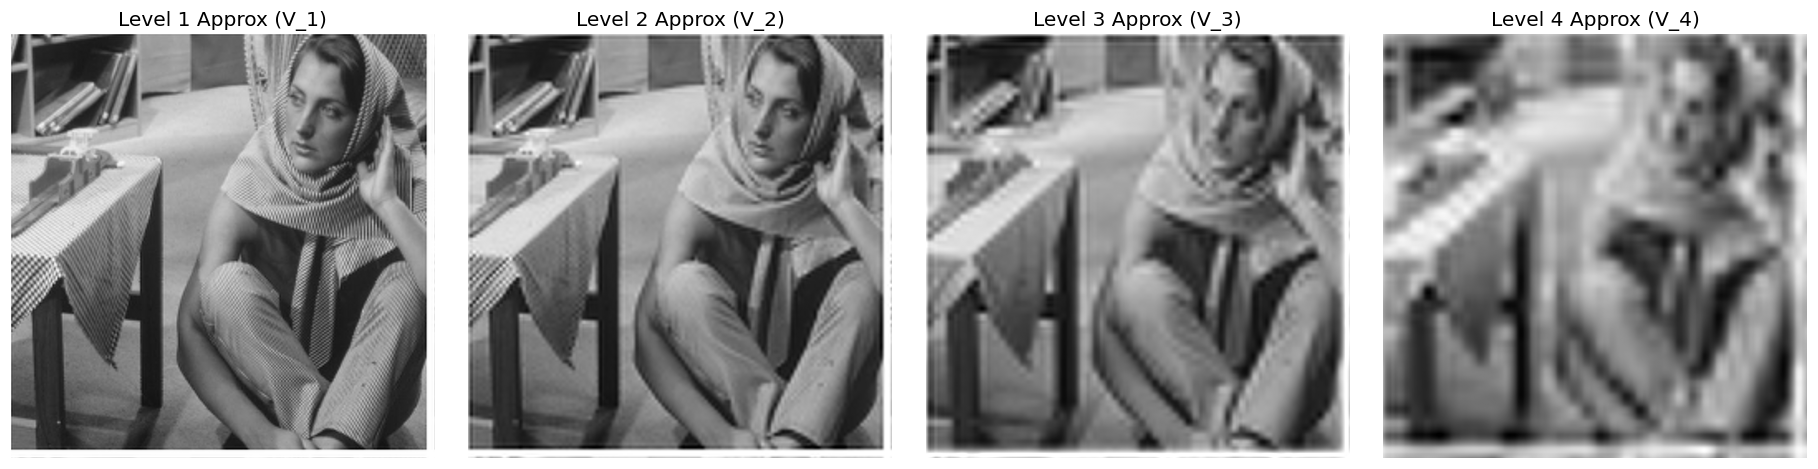

In [ ]:
# 2b — reconstruct from the approximation at each level -> projections onto V_j
import pywt
import numpy as np

MODE = 'periodization'

def approx_only(img, wavelet, level):
    coeffs = pywt.wavedec2(img, wavelet, level=level, mode=MODE)

    new_coeffs = [coeffs[0]]
    for det in coeffs[1:]:
        new_coeffs.append(tuple(np.zeros_like(b) for b in det))

    return pywt.waverec2(new_coeffs, wavelet, mode=MODE)


shells = []
titles = []
for j in range(1, 5):
    recon = approx_only(img, 'db4', j)
    shells.append(recon)
    titles.append(f"Level {j} Approx (V_{j})")

show(shells, titles=titles)


### 2c — Energy compaction
What fraction of the total coefficient energy ($\sum \alpha^2$) sits in the approximation band alone,
at each level?

In [ ]:
# 2c — energy in the approximation band vs level
import pywt
import numpy as np

print("Level | Approx Energy Fraction")
print("------------------------------")

for j in range(1, 6):
    coeffs = pywt.wavedec2(img, 'db4', level=j, mode='periodization')

    # Calculate energy of the approximation band (cA)
    approx_energy = np.sum(coeffs[0] ** 2)

    # Calculate total energy of all coefficients combined
    arr, _ = pywt.coeffs_to_array(coeffs)
    total_energy = np.sum(arr ** 2)

    fraction = approx_energy / total_energy

    print(f"  {j}   | {fraction:.6f} ({fraction * 100:.4f}%)")


Level | Approx Energy Fraction
------------------------------
  1   | 0.990253 (99.0253%)
  2   | 0.982181 (98.2181%)
  3   | 0.972401 (97.2401%)
  4   | 0.946725 (94.6725%)
  5   | 0.912490 (91.2490%)


## Part 3 — Nonlinear approximation & vanishing moments  ·  ~45 min  ·  **core**

**Goal:** the heart of the lab. Measure how well a handful of coefficients reconstruct an image,
and pin down what controls it.


### 3a — M-term nonlinear approximation
Keep the largest fraction `keep_frac` of coefficients (by magnitude), zero the rest, reconstruct.

In [ ]:
# 3a — nonlinear approximation: keep the largest coefficients
import numpy as np
import pywt

def nonlinear_approx(img, wavelet, level, keep_frac):
    """Keep the largest `keep_frac` fraction of coefficients by magnitude; reconstruct."""
    coeffs = pywt.wavedec2(img, wavelet, level=level, mode=MODE)
    arr, slices = flatten_coeffs(coeffs)

    m = int(np.round(keep_frac * arr.size))

    if m == 0:
        arr[:] = 0
    elif m < arr.size:
        sorted_abs = np.sort(np.abs(arr).ravel())
        threshold = sorted_abs[-m]

        arr[np.abs(arr) < threshold] = 0

    new_coeffs = unflatten_coeffs(arr, slices)
    return pywt.waverec2(new_coeffs, wavelet, mode=MODE)

# sanity check (leave in): keeping everything must return the original
full = nonlinear_approx(img, 'bior4.4', 4, 1.0)
print("keep_frac=1.0 round-trip error:", np.max(np.abs(full - img)))


keep_frac=1.0 round-trip error: 6.360210136335809e-10


### 3b — The error–sparsity curve
Sweep the kept fraction and plot PSNR and SSIM. This curve *is* the compressibility of the image
in this wavelet basis.

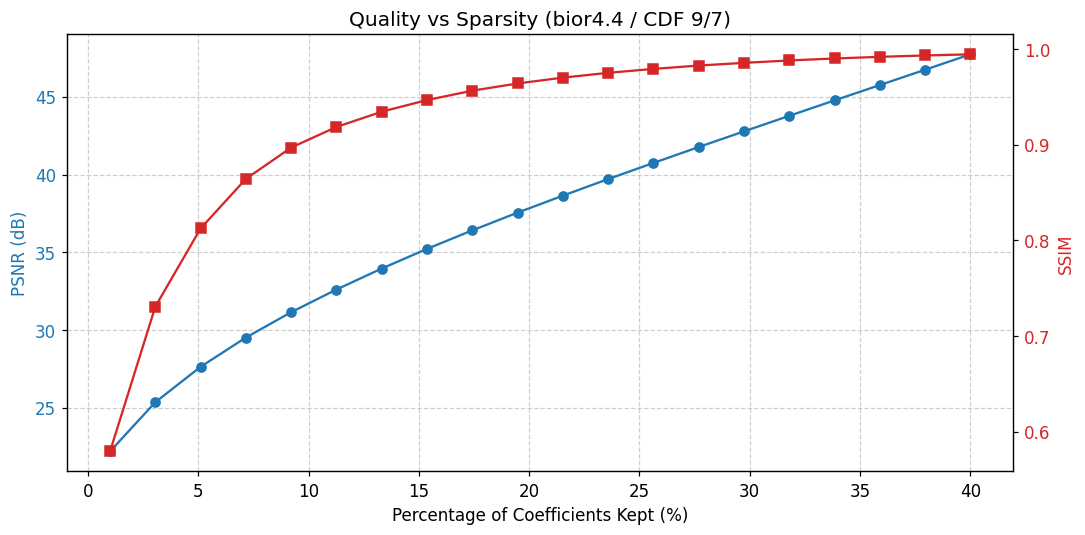

In [ ]:
# 3b — quality vs sparsity for CDF 9/7
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

fracs = np.linspace(0.01, 0.40, 20)
psnr_vals = []
ssim_vals = []

d_range = img.max() - img.min()

for f in fracs:
    recon = nonlinear_approx(img, 'bior4.4', 4, f)
    p = psnr(img, recon, data_range=d_range)
    s = ssim(img, recon, data_range=d_range)
    psnr_vals.append(p)
    ssim_vals.append(s)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'tab:blue'
ax1.set_xlabel('Percentage of Coefficients Kept (%)')
ax1.set_ylabel('PSNR (dB)', color=color1)
ax1.plot(fracs * 100, psnr_vals, marker='o', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('SSIM', color=color2)
ax2.plot(fracs * 100, ssim_vals, marker='s', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Quality vs Sparsity (bior4.4 / CDF 9/7)")
fig.tight_layout()
plt.show()


### 3c — Which wavelet approximates best?
Overlay PSNR curves for `haar`, `db4`, `bior4.4`, and show the three reconstructions at a fixed 5% budget.

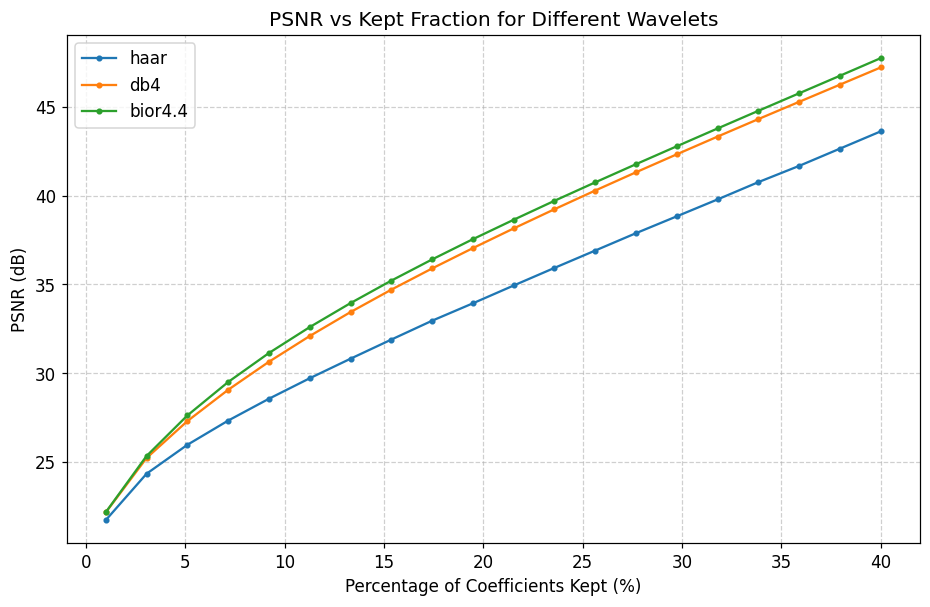

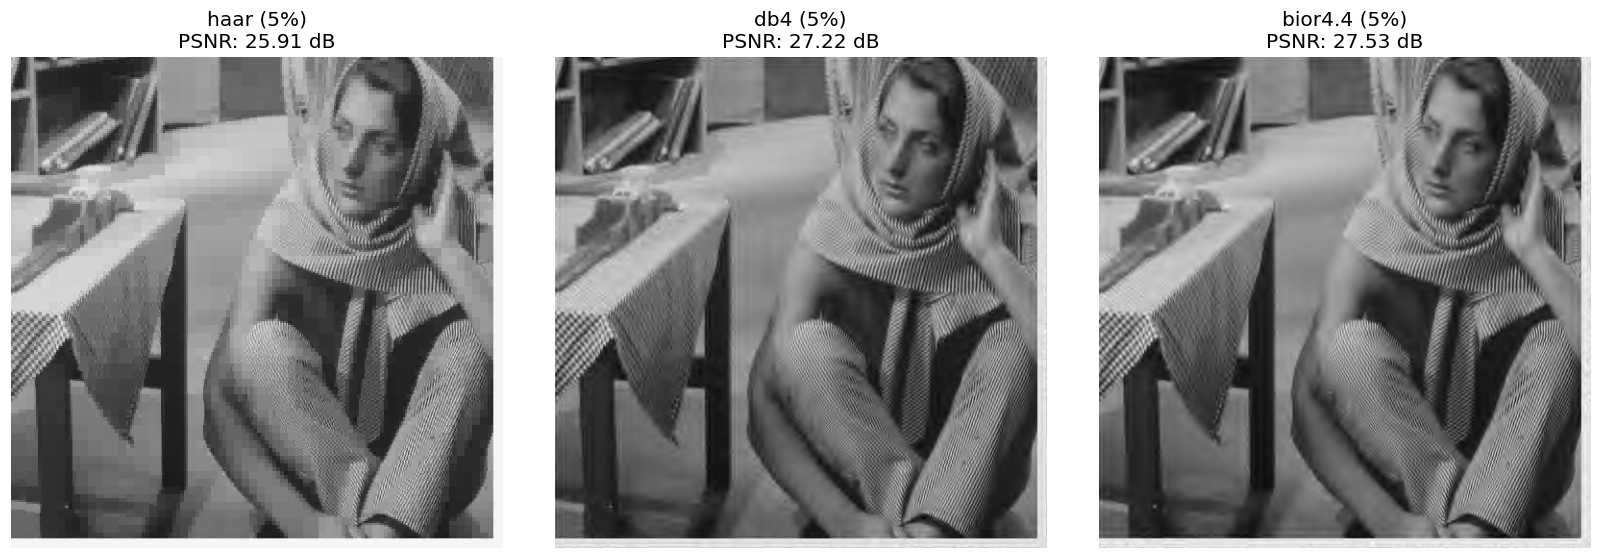

In [ ]:
# 3c — compare wavelets
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

wavelets = ['haar', 'db4', 'bior4.4']
fracs = np.linspace(0.01, 0.40, 20)
d_range = img.max() - img.min()

# First plot: Overlay PSNR curves for different wavelets on one graph
plt.figure(figsize=(10, 6))

for w in wavelets:
    psnr_vals = []
    for f in fracs:
        recon = nonlinear_approx(img, w, 4, f)
        p = psnr(img, recon, data_range=d_range)
        psnr_vals.append(p)
    plt.plot(fracs * 100, psnr_vals, label=w, marker='.')

plt.xlabel('Percentage of Coefficients Kept (%)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Kept Fraction for Different Wavelets')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Second plot: Display three reconstructions at a fixed 5% budget
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_frac = 0.05

for ax, w in zip(axes, wavelets):
    recon = nonlinear_approx(img, w, 4, target_frac)
    p = psnr(img, recon, data_range=d_range)

    ax.imshow(recon, cmap='gray')
    ax.set_title(f"{w} (5%)\nPSNR: {p:.2f} dB")
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3d — Coefficient decay (the theory link)
Sort $|\alpha|$ decreasing, plot on log–log axes, and fit the decay exponent $s$ in
$|\alpha|_{(n)} \le C\,n^{-s}$.

Fitted decay exponent (s): 1.8426


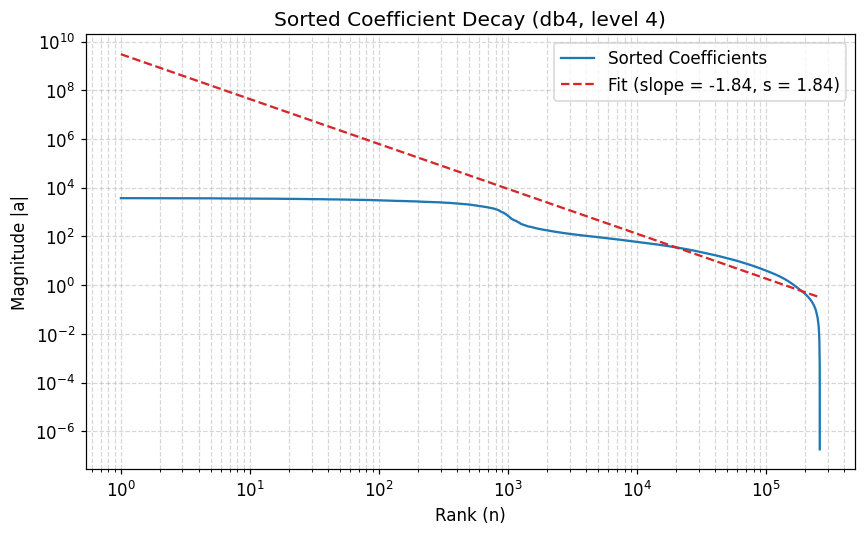

In [ ]:
# 3d — sorted coefficient decay and its power-law exponent
import numpy as np
import matplotlib.pyplot as plt
import pywt

coeffs = pywt.wavedec2(img, 'db4', level=4, mode=MODE)
arr, _ = pywt.coeffs_to_array(coeffs)
arr_flat = arr.ravel()

sorted_abs = np.sort(np.abs(arr_flat))[::-1]

valid_idx = sorted_abs > 1e-10
sorted_abs = sorted_abs[valid_idx]
ranks = np.arange(1, len(sorted_abs) + 1)

log_ranks = np.log10(ranks)
log_mags = np.log10(sorted_abs)

fit_params = np.polyfit(log_ranks, log_mags, 1)
slope = fit_params[0]
intercept = fit_params[1]
s = -slope

print(f"Fitted decay exponent (s): {s:.4f}")

plt.figure(figsize=(8, 5))
plt.loglog(ranks, sorted_abs, label='Sorted Coefficients', color='tab:blue')

fit_line = (10 ** intercept) * (ranks ** slope)
plt.loglog(ranks, fit_line, '--', color='tab:red', label=f'Fit (slope = {slope:.2f}, s = {s:.2f})')

plt.xlabel('Rank (n)')
plt.ylabel('Magnitude |a|')
plt.title('Sorted Coefficient Decay (db4, level 4)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 3e — Linear vs nonlinear
Keep the $M$ **coarsest** coefficients instead of the largest, and overlay the two curves.
Use `scale_index_array` to pick the coarsest bands.

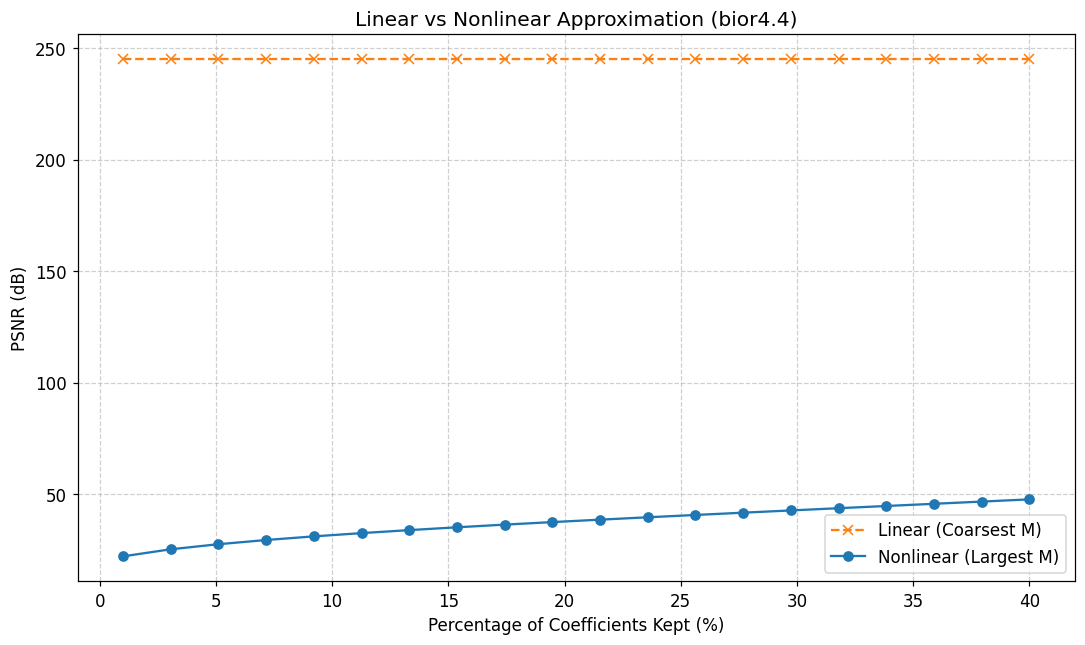

At ~5% kept, PSNR gap is -217.34 dB (Nonlinear wins)


In [ ]:
# 3e — linear approximation (keep the coarsest M) vs nonlinear (keep the largest M)
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import pywt

MODE = 'periodization'

def linear_approx(img, wavelet, level, keep_frac):
    coeffs = pywt.wavedec2(img, wavelet, level=level, mode=MODE)
    arr, slices = flatten_coeffs(coeffs)
    sidx = scale_index_array(coeffs, slices, level)

    m = int(np.round(keep_frac * arr.size))

    if m == 0:
        arr[:] = 0
    elif m < arr.size:
        # Sort coefficients by scale index (coarsest first) and keep the first m.
        sort_indices = np.argsort(sidx)
        zero_indices = sort_indices[m:]
        arr[zero_indices] = 0

    new_coeffs = unflatten_coeffs(arr, slices)
    return pywt.waverec2(new_coeffs, wavelet, mode=MODE)

# Code for plotting and comparison should be at the global scope
fracs = np.linspace(0.01, 0.40, 20)
psnr_linear = []
psnr_nonlinear = []
d_range = img.max() - img.min()
wavelet_type = 'bior4.4'

for f in fracs:
    recon_lin = linear_approx(img, wavelet_type, 4, f)
    recon_nonlin = nonlinear_approx(img, wavelet_type, 4, f)

    psnr_linear.append(psnr(img, recon_lin, data_range=d_range))
    psnr_nonlinear.append(psnr(img, recon_nonlin, data_range=d_range))

plt.figure(figsize=(10, 6))

plt.plot(fracs * 100, psnr_linear, label='Linear (Coarsest M)', marker='x', color='tab:orange', linestyle='--')
plt.plot(fracs * 100, psnr_nonlinear, label='Nonlinear (Largest M)', marker='o', color='tab:blue')

plt.xlabel('Percentage of Coefficients Kept (%)')
plt.ylabel('PSNR (dB)')
plt.title('Linear vs Nonlinear Approximation (bior4.4)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

target_idx = np.argmin(np.abs(fracs - 0.05))
gap = psnr_nonlinear[target_idx] - psnr_linear[target_idx]
print(f"At ~5% kept, PSNR gap is {gap:.2f} dB (Nonlinear wins)")

### 3f — Vanishing moments
Compare `db1 -> db2 -> db4 -> db8` at a fixed budget on a smooth image and on `fingerprint`.
When do more vanishing moments help, and when does the longer support start to hurt?

In [ ]:
# 3f — effect of vanishing moments on smooth vs textured content
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr

budget = 0.05
smooth = load_image('house', size=256)
textured = load_image('fingerprint', size=512)

wavelets = ['db1', 'db2', 'db4', 'db8']

print("Wavelet | PSNR (Smooth 'house') | PSNR (Textured 'fingerprint')")
print("-" * 65)

for w in wavelets:
    recon_smooth = nonlinear_approx(smooth, w, level=4, keep_frac=budget)
    psnr_smooth = psnr(smooth, recon_smooth, data_range=smooth.max() - smooth.min())

    recon_textured = nonlinear_approx(textured, w, level=4, keep_frac=budget)
    psnr_textured = psnr(textured, recon_textured, data_range=textured.max() - textured.min())

    print(f"  {w:4s}  |       {psnr_smooth:.2f} dB       |          {psnr_textured:.2f} dB")

Wavelet | PSNR (Smooth 'house') | PSNR (Textured 'fingerprint')
-----------------------------------------------------------------
  db1   |       32.92 dB       |          21.73 dB
  db2   |       31.24 dB       |          23.42 dB
  db4   |       31.50 dB       |          25.04 dB
  db8   |       30.51 dB       |          25.55 dB


## Part 4 — Decimated vs. undecimated  ·  ~25 min

**Goal:** feel the redundancy / shift-invariance trade-off directly, with the stationary (undecimated)
wavelet transform.


### 4a — The undecimated transform round-trips too — but it is redundant

In [ ]:
# 4a — SWT (undecimated) reconstruction and its redundancy
import pywt
import numpy as np

coeffs_swt = pywt.swt2(img, 'db2', level=3, trim_approx=True, norm=True)
img_recon = pywt.iswt2(coeffs_swt, 'db2', norm=True)

max_err = np.max(np.abs(img - img_recon))
print(f"Max reconstruction error: {max_err:.2e}")

num_coeffs = 0
for item in coeffs_swt:
    if isinstance(item, tuple):
        for subband in item:
            num_coeffs += subband.size
    else:
        num_coeffs += item.size

redundancy = num_coeffs / img.size

print(f"Original image size: {img.size}")
print(f"Stored coefficients count: {num_coeffs}")
print(f"Redundancy factor: {redundancy:.1f}x")

Max reconstruction error: 1.71e-13
Original image size: 262144
Stored coefficients count: 2621440
Redundancy factor: 10.0x


### 4b — Shift-invariance test
Approximate an image and its 1-pixel shift with the **same** budget; shift the second result back and
compare. The undecimated transform should be (essentially) shift-invariant; the decimated DWT is not.

In [ ]:
# 4b — is the M-term approximation shift-invariant?
import numpy as np
import pywt

def swt_nonlinear(img, wavelet, level, keep_frac):
    co = pywt.swt2(img, wavelet, level=level, trim_approx=True, norm=True)

    # Flatten all coefficients into a single array
    all_coeffs = [co[0].ravel()] # Approximation
    for tup in co[1:]:
        for d in tup:
            all_coeffs.append(d.ravel()) # Details
    arr = np.concatenate(all_coeffs)

    # Determine threshold to keep the top 'keep_frac' coefficients
    m = int(np.round(keep_frac * arr.size))

    if m == 0:
        threshold = np.inf
    elif m < arr.size:
        sorted_abs = np.sort(np.abs(arr))
        threshold = sorted_abs[-m] # m-th largest coefficient magnitude
    else:
        threshold = 0

    # Apply threshold to coefficients and reconstruct
    new_co = []
    new_co.append(np.where(np.abs(co[0]) < threshold, 0, co[0])) # Approximation
    for tup in co[1:]:
        new_co.append(tuple(np.where(np.abs(d) < threshold, 0, d) for d in tup)) # Details

    return pywt.iswt2(new_co, wavelet, norm=True)

# Comparison code (should be at global scope)
keep_frac = 0.05
wavelet = 'db2'
level = 3

# Shift the image by (1, 1)
img_shift = np.roll(img, shift=(1, 1), axis=(0, 1))

# DWT comparison
dwt_orig = nonlinear_approx(img, wavelet, level, keep_frac)
dwt_shift = nonlinear_approx(img_shift, wavelet, level, keep_frac)
dwt_shift_back = np.roll(dwt_shift, shift=(-1, -1), axis=(0, 1))
dwt_err = np.mean(np.abs(dwt_orig - dwt_shift_back))

# SWT comparison
swt_orig = swt_nonlinear(img, wavelet, level, keep_frac)
swt_shift = swt_nonlinear(img_shift, wavelet, level, keep_frac)
swt_shift_back = np.roll(swt_shift, shift=(-1, -1), axis=(0, 1))
swt_err = np.mean(np.abs(swt_orig - swt_shift_back))

print(f"DWT mean absolute difference: {dwt_err:.4f}")
print(f"SWT mean absolute difference: {swt_err:.4f}")

DWT mean absolute difference: 7.5221
SWT mean absolute difference: 0.0000


### 4c — *(optional)* Denoising
Add Gaussian noise, soft-threshold the details, and reconstruct with DWT and SWT. Which is cleaner?

In [ ]:
# 4c — soft-threshold denoising: DWT vs SWT (optional)
rng = np.random.default_rng(1)
sigma = 25.0
noisy = img + sigma * rng.standard_normal(img.shape)
# TODO (optional): soft-threshold the DETAIL coefficients (pywt.threshold(b, thr, 'soft'))
#       for both the DWT and the SWT with thr ~ 3*sigma; reconstruct and compare PSNR.


## Part 5 — Wavelet packets & best basis  ·  ~20 min  ·  *stretch*

**Goal:** go beyond the fixed DWT tree to a basis chosen for the signal. Wavelet packets split
**both** branches at every level; a Shannon-entropy criterion picks the best subtree.


### 5a — Packets split every branch

In [ ]:
# 5a — how many subbands does a level-3 packet tree have?
L = 3
wp = pywt.WaveletPacket2D(img, 'db2', mode=MODE, maxlevel=L)
# TODO: use wp.get_level(L) to count the leaf subbands; compare to the DWT's 3*L+1.


### 5b — Best basis by Shannon entropy
The additive Coifman–Wickerhauser cost normalises coefficient energy by the **total** signal energy
(so it is additive over an orthonormal partition). Prune bottom-up: keep a split only if it lowers the cost.

In [ ]:
# 5b — select the best basis
def build_costs(img, wavelet, L):
    wp = pywt.WaveletPacket2D(img, wavelet, mode=MODE, maxlevel=L)
    Etot = sum(float(np.sum(np.asarray(n.data, float) ** 2)) for n in wp.get_level(L))
    def cost(x):
        # TODO: additive Shannon entropy  -sum p*log p  with p = x_i^2 / Etot  (skip zeros)
        raise NotImplementedError
    costs = {n.path: cost(n.data) for lev in range(L + 1) for n in wp.get_level(lev)}
    return wp, costs

def best_basis(costs, L, path='', level=0):
    # TODO: bottom-up prune. At a leaf (level==L) return its cost. Otherwise sum the 4 children;
    #       keep the split only if the children's total cost is lower than this node's own cost.
    raise NotImplementedError

# TODO: run best_basis on 'fingerprint' (textured) and 'house' (smooth) and compare #subbands.


### 5c — Best basis vs plain DWT on `fingerprint`
Fingerprints are oscillatory texture — exactly what packets handle well (it is why fingerprint
compression standards use them). Compare the full packet basis against the DWT at the same budget.

In [ ]:
# 5c — packet M-term vs DWT M-term on fingerprint
def packet_nonlinear(img, wavelet, L, keep_frac):
    wp = pywt.WaveletPacket2D(img, wavelet, mode=MODE, maxlevel=L)
    leaves = wp.get_level(L)
    # TODO: gather all leaf coefficients, keep the top keep_frac by magnitude (threshold each leaf),
    #       then wp.reconstruct(update=False) and crop to the image shape.
    raise NotImplementedError

# TODO: compare packet_nonlinear against nonlinear_approx (DWT) on 'fingerprint' at 2%, 5%, 10%.


---
### Wrap-up
You built the transform from filters, measured what it is good for, and saw why wavelet choice,
vanishing moments, redundancy, and adaptivity all matter for approximation. Collect your Part
**Deliverables** into the short report described in the handout.
